In [2]:
# Compute and display a full one-way ANOVA for the trout-toxin example
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


In [7]:


# Data by group (unequal sample sizes)
data = {
    "Toxin 1": [28, 23, 14, 27],
    "Toxin 2": [33, 36, 34, 29, 31, 34],
    "Toxin 3": [18, 21, 20, 22, 24],
    "Control": [11, 14, 11, 16],
}

# Melt to long format
rows = []
for grp, vals in data.items():
    for v in vals:
        rows.append({"Group": grp, "Y": v})
df = pd.DataFrame(rows)

# Group stats
gstats = df.groupby("Group").agg(
    n=("Y","size"),
    mean=("Y","mean"),
    var=("Y","var"),
    sd=("Y","std")
).reset_index()

# Overall mean
grand_mean = df["Y"].mean()

# Sums of squares
# Between-groups (treatment) SS
ss_between = sum(gstats["n"] * (gstats["mean"] - grand_mean)**2)
# Within-groups (error) SS
ss_within = sum([(np.array(vals) - np.mean(vals)).var(ddof=1) * (len(vals)-1) for vals in data.values()])
# Total SS
ss_total = ((df["Y"] - grand_mean)**2).sum()

k = len(data)
N = len(df)
df_between = k - 1
df_within = N - k
ms_between = ss_between / df_between
ms_within = ss_within / df_within
F = ms_between / ms_within
p_value = 1 - stats.f.cdf(F, df_between, df_within)

anova_table = pd.DataFrame({
    "Source": ["Treatment", "Error", "Total"],
    "SS": [ss_between, ss_within, ss_total],
    "df": [df_between, df_within, N-1],
    "MS": [ms_between, ms_within, ""],
    "F": [F, "", ""],
    "p-value": [p_value, "", ""],
})



In [ ]:
# Display data;

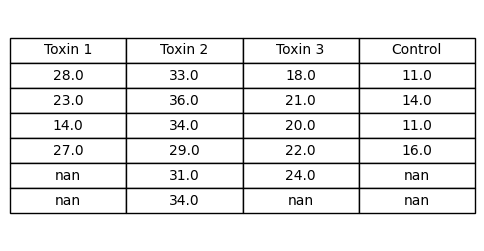

In [23]:
data1 = {
    "Toxin 1": [28, 23, 14, 27, None, None],
    "Toxin 2": [33, 36, 34, 29, 31, 34],
    "Toxin 3": [18, 21, 20, 22, 24, None],
    "Control": [11, 14, 11, 16, None, None]
}

df = pd.DataFrame(data1)
# Plot the table
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values,
                 colLabels=df.columns,
                 loc='center',
                 cellLoc='center')
# Adjust row height
table.scale(1, 1.5)

plt.show()

In [8]:

# Display results
display("One-Way ANOVA Table (Trout toxins)", anova_table.round(4))
display("Group Descriptives", gstats.round(3))


'One-Way ANOVA Table (Trout toxins)'

,Source,SS,df,MS,F,p-value
0,Treatment,995.9035,3,331.967836,26.093542,0.000003
1,Error,190.8333,15,12.722222,,
2,Total,1186.7368,18,,,


'Group Descriptives'

,Group,n,mean,var,sd
0,Control,4,13.000,6.000,2.449
1,Toxin 1,4,23.000,40.667,6.377
2,Toxin 2,6,32.833,6.167,2.483
3,Toxin 3,5,21.000,5.000,2.236


<Figure size 640x480 with 0 Axes>

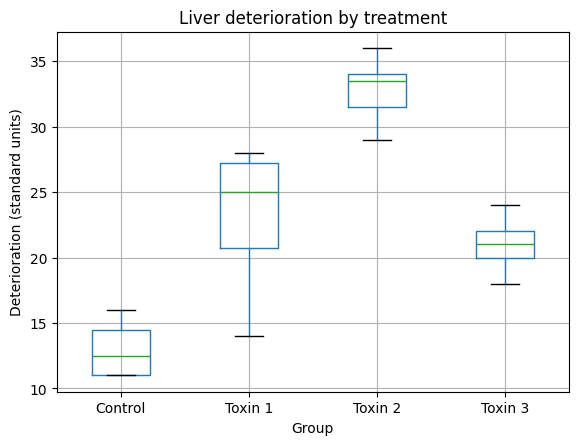

In [9]:
# Simple boxplot for quick visual comparison
plt.figure()
df.boxplot(by="Group", column="Y")
plt.title("Liver deterioration by treatment")
plt.suptitle("")
plt.xlabel("Group")
plt.ylabel("Deterioration (standard units)")
plt.show()


In [10]:

# Also show means with 95% CI using t critical within each group for illustration
means_ci = []
for grp, vals in data.items():
    a = np.array(vals)
    n = len(a)
    m = a.mean()
    s = a.std(ddof=1)
    tcrit = stats.t.ppf(0.975, df=n-1)
    me = tcrit * s / np.sqrt(n)
    means_ci.append({"Group": grp, "Mean": m, "Lower 95%": m - me, "Upper 95%": m + me, "n": n})
cis = pd.DataFrame(means_ci)
display("Group Means with 95% CI (unpooled, descriptive)", cis.round(3))

'Group Means with 95% CI (unpooled, descriptive)'

,Group,Mean,Lower 95%,Upper 95%,n
0,Toxin 1,23.000,12.853,33.147,4
1,Toxin 2,32.833,30.227,35.439,6
2,Toxin 3,21.000,18.224,23.776,5
3,Control,13.000,9.102,16.898,4
